# The Imagination Machine III
## Universal Spectral Representation via Cyclic Lifting
### Stochastic Extension: Markov Chain Environments

This notebook implements the stochastic extension of the TIM III cyclic lifting
experiment. Rather than deterministic periodic sequences (unit fractions), each
environment is a randomly sampled stationary Markov chain over Z/10Z. The
ground-truth probe targets are the real and imaginary parts of the dominant
eigenvalues of each environment's known transition matrix.

The lifting, architecture, and probe protocol are identical to the canonical
TIM III notebook. The sole change is the environment source: instead of a fixed
pool of fractions with known periods, each environment is a fresh Dirichlet-
sampled transition matrix with its own spectral structure.

This experiment tests Conjecture 2 (Universal Spectral Recovery) in the
stochastic setting: whether the bottleneck linearly encodes the dominant Fourier
modes of the transition distribution from prediction error alone, for processes
where the spectrum is not known in advance and cannot be derived from a period.

**Notebook structure:**
- Cell 1 — SCC installation
- Cell 2 — Imports, configuration, master seed
- Cell 3 — Markov chain environment model and observation generator
- Cell 4 — Agent architecture (unchanged from TIM X)
- Cell 5 — vmap infrastructure (unchanged from TIM X)
- Cell 6 — Learning rate search (optional, commented out)
- Cell 7 — Parallel training loop (incremental save, per-device queue)
- Cell 8 — Save / load dataset
- Cell 9 — Normalize weight vectors
- Cell 10 — Environment sanity check
- Cell 11 — Linear probe: eigenvalue targets, k-fold CV
- Cell 12 — Metric decomposition
- Cell 13 — Visualization


In [1]:
# ============================================================
# Cell 1 | Installation (SCC)
# ============================================================
#
# Installs PyTorch to the project directory only if not already
# available. Run once; subsequent runs skip the install.
# ============================================================

import sys, subprocess

install_dir = ""

if install_dir not in sys.path:
    sys.path.insert(0, install_dir)

try:
    import torch
    print(f"PyTorch {torch.__version__} already available -- skipping install.")
except ImportError:
    print("PyTorch not found -- installing...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "--target", install_dir,
        "--upgrade",
        "torch",
    ])
    print(f"Installation complete -> {install_dir}")
    print("Restart the kernel, then run from Cell 2.")

PyTorch 2.12.0+cu130 already available -- skipping install.


In [2]:
# ============================================================
# Cell 2 (TIM III Markov) | Imports, Configuration, Master Seed
# ============================================================

import sys
sys.path.insert(0, "")

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, List

# --- Reproducibility ---
MASTER_SEED   = 76
SEED_ENV      = MASTER_SEED + 1   # seeds q sampling
SEED_WEIGHTS  = MASTER_SEED + 2   # base seed; init m uses SEED_WEIGHTS + m
SEED_TRAINING = MASTER_SEED + 3

# --- Environment ---
M_CYCLIC      = 10                # cyclic group order (alphabet size)
Q_MIN         = 0.01              # minimum asymmetry parameter
Q_MAX         = 0.99              # maximum asymmetry parameter
                                  # q=0.5 -> symmetric walk, real eigenvalues
                                  # q!=0.5 -> asymmetric, complex eigenvalues
N_PROBE_MODES = 3                 # dominant eigenvalue modes to probe

# --- Agent ---
OBS_DIM        = 6
STATE_DIM      = 32
MLP_HIDDEN_DIM = 32               

# --- Training ---
N_ENVS            = 5000           # smoke test; scale to 5000 after validation
N_INITS           = 15             # set to 10 for ensemble run
T_STEPS           = 200
N_EPOCHS_PER_ENV  = 100
LEARNING_RATE     = 5e-3
VMAP_CHUNK_SIZE   = 50
CONTEXT_NORMALIZE = False

# --- Probe ---
PROBE_K_FOLDS = 5

# --- I/O ---
LOAD_FROM_DISK = True
SAVE_DIR_ROOT  = ""

# --- Devices ---
DEVICE  = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DEVICES = [torch.device(f"cuda:{i}")
           for i in range(torch.cuda.device_count())] or [DEVICE]

torch.manual_seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

print(f"Cyclic group     : Z/{M_CYCLIC}Z")
print(f"Q range          : [{Q_MIN}, {Q_MAX}]")
print(f"Environments     : {N_ENVS}")
print(f"Inits/env (M)    : {N_INITS}")
print(f"T_STEPS          : {T_STEPS}")
print(f"Epochs/env       : {N_EPOCHS_PER_ENV}")
print(f"OBS_DIM          : {OBS_DIM}")
print(f"STATE_DIM        : {STATE_DIM}")
print(f"MLP_HIDDEN_DIM   : {MLP_HIDDEN_DIM}  (bottleneck: {MLP_HIDDEN_DIM} < {STATE_DIM})")
print(f"Devices          : {DEVICES}")

Cyclic group     : Z/10Z
Q range          : [0.01, 0.99]
Environments     : 5000
Inits/env (M)    : 15
T_STEPS          : 200
Epochs/env       : 100
OBS_DIM          : 6
STATE_DIM        : 32
MLP_HIDDEN_DIM   : 32  (bottleneck: 32 < 32)
Devices          : [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]


In [3]:
# ============================================================
# Cell 3 (TIM III Markov) | Nearest-Neighbor Random Walk
# ============================================================
#
# Each environment is a nearest-neighbor random walk on Z/MZ
# parameterized by a single asymmetry parameter q in (0,1).
#
# Transition matrix:
#   P[i, (i+1) % M] = q       (step right)
#   P[i, (i-1) % M] = 1 - q   (step left)
#   P[i, j]         = 0       otherwise
#
# This is a circulant matrix. Its eigenvalues are:
#   lambda_k = q * exp(2pi*i*k/M) + (1-q) * exp(-2pi*i*k/M)
#            = cos(2pi*k/M) + i*(2q-1)*sin(2pi*k/M)
#
# Re(lambda_k) = cos(2pi*k/M) is constant across environments
# and carries no information about q. Only the imaginary parts
#   Im(lambda_k) = (2q-1) * sin(2pi*k/M)
# vary with q and constitute the probe targets.
#
# q is drawn uniformly from [Q_MIN, Q_MAX]. The stationary
# distribution is uniform for all q (circulant chain).
#
# Observation model: identical to canonical TIM X.
# ============================================================

# --- Transition matrix construction ---

def make_rw_transition_matrix(q: float, M: int) -> np.ndarray:
    P = np.zeros((M, M), dtype=np.float64)
    for i in range(M):
        P[i, (i + 1) % M] = q
        P[i, (i - 1) % M] = 1.0 - q
    return P


# --- Trajectory generation ---

def sample_trajectory_rw(q: float, M: int, T: int, rng: np.random.Generator) -> np.ndarray:
    x      = rng.integers(0, M)
    states = [x]
    for _ in range(T + 2):
        if rng.random() < q:
            x = (x + 1) % M
        else:
            x = (x - 1) % M
        states.append(x)
    return np.array(states, dtype=np.int32)


# --- Observation model (identical to canonical TIM X) ---

def observe_cyclic(digits_window: np.ndarray, M: int = 10) -> np.ndarray:
    T_plus_1 = len(digits_window) - 2
    d12_raw  = (digits_window[:T_plus_1]    - digits_window[1:T_plus_1+1]) % M
    d13_raw  = (digits_window[:T_plus_1]    - digits_window[2:T_plus_1+2]) % M
    d23_raw  = (digits_window[1:T_plus_1+1] - digits_window[2:T_plus_1+2]) % M
    d12 = (2.0 * np.pi * d12_raw / M) % (2.0 * np.pi)
    d13 = (2.0 * np.pi * d13_raw / M) % (2.0 * np.pi)
    d23 = (2.0 * np.pi * d23_raw / M) % (2.0 * np.pi)
    return np.stack([
        np.cos(d12), np.sin(d12),
        np.cos(d13), np.sin(d13),
        np.cos(d23), np.sin(d23),
    ], axis=1).astype(np.float32)


def make_trajectory_markov(states: np.ndarray, T: int, M: int = 10) -> np.ndarray:
    return observe_cyclic(states[:T+3], M)


# --- Probe target computation ---

def rw_eigenvalues(q: float, M: int, n_modes: int) -> np.ndarray:
    """
    Probe targets: imaginary parts of dominant eigenvalues only.
    Im(lambda_k) = (2q-1) * sin(2pi*k/M)
    Re(lambda_k) = cos(2pi*k/M) is constant across environments
    and carries no information about q -- excluded.
    """
    targets = []
    for k in range(1, n_modes + 1):
        angle = 2.0 * np.pi * k / M
        im    = (2.0 * q - 1.0) * np.sin(angle)
        targets.append(im)
    return np.array(targets, dtype=np.float32)


def get_target_names() -> list:
    return [f"Im(lambda_{k})" for k in range(1, N_PROBE_MODES + 1)]


# --- Environment pool instantiation ---

def sample_rw_environments(n_envs: int, T: int, M: int, seed: int):
    rng       = np.random.default_rng(seed)
    qs        = rng.uniform(Q_MIN, Q_MAX, size=n_envs)
    traj_list = []
    targets   = np.zeros((n_envs, N_PROBE_MODES), dtype=np.float32)

    for i, q in enumerate(qs):
        traj       = sample_trajectory_rw(q, M, T, rng)
        targets[i] = rw_eigenvalues(q, M, N_PROBE_MODES)
        traj_list.append(traj)

    return traj_list, qs, targets


traj_list, qs, targets_markov = sample_rw_environments(
    n_envs = N_ENVS,
    T      = T_STEPS,
    M      = M_CYCLIC,
    seed   = SEED_ENV,
)

TARGET_NAMES = get_target_names()

print(f"Environments     : {N_ENVS}")
print(f"q range          : [{qs.min():.4f}, {qs.max():.4f}]  mean={qs.mean():.4f}")
print(f"Trajectories     : {len(traj_list)}  each length {T_STEPS+3}")
print(f"Probe targets    : {targets_markov.shape}")
print(f"Target names     : {TARGET_NAMES}")
print()
for i, name in enumerate(TARGET_NAMES):
    col = targets_markov[:, i]
    print(f"  {name:<20} range [{col.min():+.4f}, {col.max():+.4f}]  "
          f"mean={col.mean():+.4f}  std={col.std():.4f}")

# Sanity check: verify closed-form against matrix eigenvalues for one env
_P      = make_rw_transition_matrix(qs[0], M_CYCLIC)
_evals  = np.linalg.eigvals(_P)
_cf     = rw_eigenvalues(qs[0], M_CYCLIC, N_PROBE_MODES)
_k1_im  = float(_evals[np.argmin(np.abs(_evals - (np.cos(2*np.pi/M_CYCLIC) + 1j*(2*qs[0]-1)*np.sin(2*np.pi/M_CYCLIC))))].imag)
print(f"\nEigenvalue sanity check (env 0, q={qs[0]:.4f}):")
print(f"  closed-form Im(lambda_1) = {_cf[0]:+.6f}")
print(f"  matrix      Im(lambda_1) = {_k1_im:+.6f}")

_test_obs = make_trajectory_markov(traj_list[0], T_STEPS, M_CYCLIC)
assert _test_obs.shape == (T_STEPS + 1, 6), f"Shape mismatch: {_test_obs.shape}"
assert not np.isnan(targets_markov).any(), "NaN in targets"
print(f"\nTrajectory shape : passed  {_test_obs.shape}")
print(f"Targets NaN-free : passed")

Environments     : 5000
q range          : [0.0100, 0.9896]  mean=0.4960
Trajectories     : 5000  each length 203
Probe targets    : (5000, 3)
Target names     : ['Im(lambda_1)', 'Im(lambda_2)', 'Im(lambda_3)']

  Im(lambda_1)         range [-0.5760, +0.5756]  mean=-0.0047  std=0.3322
  Im(lambda_2)         range [-0.9320, +0.9313]  mean=-0.0076  std=0.5375
  Im(lambda_3)         range [-0.9320, +0.9313]  mean=-0.0076  std=0.5375

Eigenvalue sanity check (env 0, q=0.7802):
  closed-form Im(lambda_1) = +0.329411
  matrix      Im(lambda_1) = +0.329411

Trajectory shape : passed  (201, 6)
Targets NaN-free : passed


In [4]:
# ============================================================
# Cell 4 (TIM III Markov) | Agent Architecture
# ============================================================
#
# Identical to canonical TIM V/X architecture. No changes
# required for the Markov setting.
#
# Four structural commitments:
#
#   1. Observation LayerNorm: o̊ₜ = LayerNorm(oₜ)
#   2. Residual state update with LayerNorm:
#        sₜ₊₁ = LayerNorm(sₜ + MLP_u([sₜ, o̊ₜ]))
#   3. Bottleneck: d_h < d_s + d_o
#      Layer structure:
#        Linear(STATE_DIM + OBS_DIM → MLP_HIDDEN_DIM)
#        ReLU
#        Linear(MLP_HIDDEN_DIM → MLP_HIDDEN_DIM)
#        ReLU
#        Linear(MLP_HIDDEN_DIM → STATE_DIM)
#   4. Linear prediction head: ôₜ₊₁ = W[sₜ₊₁, o̊ₜ] + b
#
# The full converged parameter vector is saved after training.
# Downstream probe cells draw random same-size slices from the
# full vector to test for distributed Koopman encoding.
# ============================================================


class QuasiPeriodicAgent(nn.Module):
    """
    Predictive agent with two-layer MLP state update,
    residual connection, LayerNorm state stabilization,
    observation LayerNorm, and a linear prediction head.

    Parameters
    ----------
    obs_dim    : dimension of relational observation (default 6)
    state_dim  : dimension of internal state
    hidden_dim : dimension of both hidden layers
    """

    def __init__(
        self,
        obs_dim:    int = OBS_DIM,
        state_dim:  int = STATE_DIM,
        hidden_dim: int = MLP_HIDDEN_DIM,
    ) -> None:
        super().__init__()
        self.obs_dim   = obs_dim
        self.state_dim = state_dim

        self.obs_norm = nn.LayerNorm(obs_dim)

        self.state_update = nn.Sequential(
            nn.Linear(state_dim + obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim),
        )

        self.prediction_head = nn.Linear(state_dim + obs_dim, obs_dim)
        self.state_norm      = nn.LayerNorm(state_dim)

    def forward(
        self,
        s: torch.Tensor,
        o: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        o_normed = self.obs_norm(o)
        s_next   = self.state_norm(
            s + self.state_update(torch.cat([s, o_normed], dim=-1))
        )
        o_pred   = self.prediction_head(torch.cat([s_next, o_normed], dim=-1))
        return s_next, o_pred

    def init_state(
        self,
        batch_size: int,
        device:     torch.device,
    ) -> torch.Tensor:
        return torch.zeros(batch_size, self.state_dim, device=device)


torch.manual_seed(SEED_WEIGHTS)
agent = QuasiPeriodicAgent(
    obs_dim    = OBS_DIM,
    state_dim  = STATE_DIM,
    hidden_dim = MLP_HIDDEN_DIM,
).to(DEVICE)

n_params = sum(p.numel() for p in agent.parameters() if p.requires_grad)

print(agent)
print(f"\nTotal trainable parameters : {n_params}")

QuasiPeriodicAgent(
  (obs_norm): LayerNorm((6,), eps=1e-05, elementwise_affine=True, bias=True)
  (state_update): Sequential(
    (0): Linear(in_features=38, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
  )
  (prediction_head): Linear(in_features=38, out_features=6, bias=True)
  (state_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
)

Total trainable parameters : 3670


In [5]:
# ============================================================
# Cell 5 (TIM III Markov) | Functional Forward Pass and vmap
# ============================================================
# Identical to canonical TIM X, with make_obs_batch_markov
# replacing make_obs_batch_cyclic.
#
# The full converged parameter vector is saved after training.
# Downstream probe cells draw random same-size slices from the
# full vector to test for distributed Koopman encoding.
# ============================================================

from torch.func import functional_call, vmap, grad


# --- Parameter shape registry ---
_ref_agent   = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
PARAM_SHAPES = {
    name: p.shape
    for name, p in _ref_agent.named_parameters()
}
PARAM_SLICES = {}
offset = 0
for name, shape in PARAM_SHAPES.items():
    numel = int(np.prod(shape))
    PARAM_SLICES[name] = (offset, offset + numel)
    offset += numel
TOTAL_PARAM_DIM = offset
del _ref_agent

print(f"Total agent parameters : {TOTAL_PARAM_DIM}")
print(f"Parameter names        : {list(PARAM_SHAPES.keys())}")


def vector_to_params(vec: torch.Tensor) -> dict:
    return {
        name: vec[start:end].reshape(PARAM_SHAPES[name])
        for name, (start, end) in PARAM_SLICES.items()
    }


def params_to_vector(params: dict) -> torch.Tensor:
    return torch.cat([p.flatten() for p in params.values()])


def get_module(device: torch.device) -> QuasiPeriodicAgent:
    return QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM).to(device)


def make_functional_loss(device: torch.device):
    module = get_module(device)
    s_init = torch.zeros(1, STATE_DIM, device=device)

    def functional_loss(vec: torch.Tensor, obs: torch.Tensor) -> torch.Tensor:
        params = vector_to_params(vec)
        s      = s_init
        total  = torch.tensor(0.0, device=device)
        for t in range(T_STEPS):
            s, o_pred = functional_call(
                module, params, (s, obs[t].unsqueeze(0))
            )
            total = total + nn.functional.mse_loss(
                o_pred, obs[t + 1].unsqueeze(0)
            )
        return total / T_STEPS

    batched_loss = vmap(functional_loss, in_dims=(0, 0))
    batched_grad = vmap(grad(functional_loss), in_dims=(0, 0))

    return functional_loss, batched_loss, batched_grad


def init_param_batch(B: int, device: torch.device) -> torch.Tensor:
    torch.manual_seed(SEED_WEIGHTS)
    ref = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
    vec = params_to_vector(dict(ref.named_parameters()))
    return vec.unsqueeze(0).expand(B, -1).clone().to(device)


def adam_init(B: int, device: torch.device) -> dict:
    return {
        "m": torch.zeros(B, TOTAL_PARAM_DIM, device=device),
        "v": torch.zeros(B, TOTAL_PARAM_DIM, device=device),
        "t": 0,
    }


def adam_step(
    vecs:  torch.Tensor,
    grads: torch.Tensor,
    state: dict,
    lr:    float,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps:   float = 1e-8,
) -> Tuple[torch.Tensor, dict]:
    state["t"] += 1
    t          = state["t"]
    state["m"] = beta1 * state["m"] + (1 - beta1) * grads
    state["v"] = beta2 * state["v"] + (1 - beta2) * grads ** 2
    m_hat      = state["m"] / (1 - beta1 ** t)
    v_hat      = state["v"] / (1 - beta2 ** t)
    return vecs - lr * m_hat / (v_hat.sqrt() + eps), state


def clip_grads(grads: torch.Tensor, max_norm: float = 1.0) -> torch.Tensor:
    norms = grads.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    scale = (max_norm / norms).clamp(max=1.0)
    return grads * scale


def make_obs_batch_markov(
    traj_batch: list,
    T:          int,
    device:     torch.device,
    M:          int = M_CYCLIC,
) -> torch.Tensor:
    obs = np.stack([
        make_trajectory_markov(traj_batch[b], T, M)
        for b in range(len(traj_batch))
    ])
    return torch.tensor(obs, dtype=torch.float32, device=device)

Total agent parameters : 3670
Parameter names        : ['obs_norm.weight', 'obs_norm.bias', 'state_update.0.weight', 'state_update.0.bias', 'state_update.2.weight', 'state_update.2.bias', 'state_update.4.weight', 'state_update.4.bias', 'prediction_head.weight', 'prediction_head.bias', 'state_norm.weight', 'state_norm.bias']


In [6]:
# ============================================================
# Cell 6 (TIM III Markov) | Learning Rate Search
# ============================================================

from concurrent.futures import ThreadPoolExecutor
import threading

LR_CANDIDATES    = [1e-2, 5e-3, 1e-3, 5e-4]
LR_SEARCH_EPOCHS = 100
LR_SEARCH_N_ENVS = min(200, VMAP_CHUNK_SIZE)

if not LOAD_FROM_DISK:
    search_trajs  = traj_list[:LR_SEARCH_N_ENVS]
    lr_print_lock = threading.Lock()
    lr_results    = {}

    def run_lr_candidate(lr_idx):
        lr     = LR_CANDIDATES[lr_idx]
        device = DEVICES[lr_idx % len(DEVICES)]
        _, batched_loss, batched_grad = make_functional_loss(device)
        vecs         = init_param_batch(LR_SEARCH_N_ENVS, device)
        opt          = adam_init(LR_SEARCH_N_ENVS, device)
        obs          = make_obs_batch_markov(search_trajs, T_STEPS, device=device)
        final_losses = None

        for epoch in range(LR_SEARCH_EPOCHS):
            grads = batched_grad(vecs, obs)
            grads = clip_grads(grads, max_norm=1.0)
            vecs, opt = adam_step(vecs, grads, opt, lr=lr)

            if (epoch + 1) % 20 == 0 or epoch == LR_SEARCH_EPOCHS - 1:
                with torch.no_grad():
                    losses = batched_loss(vecs, obs).detach().cpu().numpy()
                mean_loss = float(losses.mean())
                with lr_print_lock:
                    print(f"  lr={lr:.0e}  epoch {epoch+1:>3}/{LR_SEARCH_EPOCHS}  "
                          f"loss: {mean_loss:.6f}  device: {device}")

        with torch.no_grad():
            final_losses = batched_loss(vecs, obs).detach().cpu().numpy()
        result = float(final_losses.mean())
        with lr_print_lock:
            print(f"  lr={lr:.0e}  DONE  mean: {result:.6f}  device: {device}")
        return lr, result

    print(f"LR search: {LR_SEARCH_EPOCHS} epochs, "
          f"{LR_SEARCH_N_ENVS} envs per candidate, "
          f"{len(LR_CANDIDATES)} candidates\n")
    print(f"{'LR':<12}  {'Epoch':>8}  {'Mean Loss':>12}")
    print("-" * 38)

    with ThreadPoolExecutor(max_workers=len(DEVICES)) as executor:
        futures = [executor.submit(run_lr_candidate, i)
                   for i in range(len(LR_CANDIDATES))]
        for future in futures:
            lr, result = future.result()
            lr_results[lr] = result

    valid_results = {lr: loss for lr, loss in lr_results.items()
                     if np.isfinite(loss)}
    best_lr       = min(valid_results, key=valid_results.get)
    LEARNING_RATE = best_lr
    print(f"\nAll results   : {lr_results}")
    print(f"Best LR       : {LEARNING_RATE}")

print(f"\nLearning rate : {LEARNING_RATE}")

In [7]:
# ============================================================
# Cell 7 (TIM III Markov) | Parallel Ensemble Training Loop
# ============================================================
#
# Ensemble variant: N_INITS differently-initialized agents are
# trained per environment on the same trajectory. After
# training, the N_INITS full parameter vectors are mean-pooled
# to produce a single vector per environment.
#
# The full pooled parameter vector is retained per environment.
# Slicing for random control probes is done downstream in
# Cell 10.
#
# Concurrency model: one worker per GPU, one chunk per GPU at
# a time. Incremental saving: each chunk written to CHUNK_DIR
# on completion. Fully resumable on rerun.
#
# Output:
#   full_params  : (N_ENVS, TOTAL_PARAM_DIM)
#   agent_losses : (N_ENVS, N_INITS)
# ============================================================

import time, os, queue, threading
from concurrent.futures import ThreadPoolExecutor

print_lock = threading.Lock()
N_DEVICES  = len(DEVICES)

CHUNK_DIR = (f"{SAVE_DIR_ROOT}/chunks/markov_rw"
             f"_M_{M_CYCLIC}"
             f"_q_{Q_MIN}_{Q_MAX}"
             f"_n_{N_ENVS}_inits_{N_INITS}_modes_{N_PROBE_MODES}"
             f"_s_{STATE_DIM}_h_{MLP_HIDDEN_DIM}"
             f"_t_{T_STEPS}_nep_{N_EPOCHS_PER_ENV}")
os.makedirs(CHUNK_DIR, exist_ok=True)


def chunk_path(c):
    return os.path.join(CHUNK_DIR, f"chunk_{c:04d}.npz")

def chunk_done(c):
    return os.path.exists(chunk_path(c))

def save_chunk(c, pooled_vecs, final_losses):
    np.savez(chunk_path(c), pooled_vecs=pooled_vecs, final_losses=final_losses)

def load_chunk(c):
    data = np.load(chunk_path(c))
    return data["pooled_vecs"], data["final_losses"]


def init_param_batch_ensemble(B: int, device: torch.device) -> torch.Tensor:
    """
    Build B * N_INITS param vectors.
    Init m uses seed SEED_WEIGHTS + m, identical across all environments.
    Returns (B * N_INITS, TOTAL_PARAM_DIM).
    """
    init_vecs = []
    for m in range(N_INITS):
        torch.manual_seed(SEED_WEIGHTS + m)
        ref = QuasiPeriodicAgent(OBS_DIM, STATE_DIM, MLP_HIDDEN_DIM)
        vec = params_to_vector(dict(ref.named_parameters()))
        init_vecs.append(vec)
    stacked = torch.stack(init_vecs, dim=0)
    tiled   = stacked.unsqueeze(0).expand(B, -1, -1)
    return tiled.reshape(B * N_INITS, -1).clone().to(device)


def expand_obs_for_ensemble(obs: torch.Tensor) -> torch.Tensor:
    B, Tp1, D = obs.shape
    obs_exp = obs.unsqueeze(1).expand(-1, N_INITS, -1, -1)
    return obs_exp.reshape(B * N_INITS, Tp1, D)


def pool_params(vecs: np.ndarray, B: int) -> np.ndarray:
    """
    Mean-pool N_INITS full parameter vectors per environment.
    (B * N_INITS, TOTAL_PARAM_DIM)  ->  (B, TOTAL_PARAM_DIM)
    """
    return vecs.reshape(B, N_INITS, -1).mean(axis=1)


def print_chunk_progress(chunk_idx, epoch, n_chunks, device, mean_loss=None):
    if (epoch + 1) % 10 != 0 and epoch != N_EPOCHS_PER_ENV - 1:
        return
    loss_str = f"  loss: {mean_loss:.6f}" if mean_loss is not None else ""
    with print_lock:
        print(
            f"chunk {chunk_idx+1:>3}/{n_chunks}  "
            f"epoch {epoch+1:>3}/{N_EPOCHS_PER_ENV}  "
            f"device: {device}{loss_str}"
        )


def train_chunk(chunk_trajs, chunk_idx, n_chunks, device):
    B = len(chunk_trajs)
    _, batched_loss, batched_grad = make_functional_loss(device)

    vecs = init_param_batch_ensemble(B, device)
    opt  = adam_init(B * N_INITS, device)

    obs_B = make_obs_batch_markov(chunk_trajs, T_STEPS, device=device)
    obs   = expand_obs_for_ensemble(obs_B)

    final_losses_flat = None

    for epoch in range(N_EPOCHS_PER_ENV):
        grads = batched_grad(vecs, obs)
        grads = clip_grads(grads, max_norm=1.0)
        vecs, opt = adam_step(vecs, grads, opt, lr=LEARNING_RATE)

        if epoch == N_EPOCHS_PER_ENV - 1:
            with torch.no_grad():
                final_losses_flat = batched_loss(vecs, obs).detach().cpu().numpy()

        print_chunk_progress(
            chunk_idx, epoch, n_chunks, device,
            mean_loss=float(final_losses_flat.mean()) if final_losses_flat is not None else None,
        )

    mean = float(final_losses_flat.mean())
    std  = float(final_losses_flat.std())
    with print_lock:
        print(
            f"chunk {chunk_idx+1:>3}/{n_chunks}  complete  "
            f"mean: {mean:.6f}  std: {std:.6f}  device: {device}"
        )

    full_vecs_flat = vecs.detach().cpu().numpy()      # (B*N_INITS, TOTAL_PARAM_DIM)
    pooled_vecs    = pool_params(full_vecs_flat, B)   # (B, TOTAL_PARAM_DIM)
    final_losses   = final_losses_flat.reshape(B, N_INITS)

    return chunk_idx, pooled_vecs, final_losses


def collect_all_final_states(traj_list):
    """
    Returns
    -------
    full_params  : (N_ENVS, TOTAL_PARAM_DIM)
    all_losses   : (N_ENVS, N_INITS)
    """
    N        = len(traj_list)
    n_chunks = int(np.ceil(N / VMAP_CHUNK_SIZE))

    full_params = np.zeros((N, TOTAL_PARAM_DIM), dtype=np.float32)
    all_losses  = np.zeros((N, N_INITS),         dtype=np.float32)

    n_cached = 0
    pending  = []
    for c in range(n_chunks):
        start = c * VMAP_CHUNK_SIZE
        end   = min(start + VMAP_CHUNK_SIZE, N)
        if chunk_done(c):
            chunk_vecs, chunk_losses = load_chunk(c)
            full_params[start:end]   = chunk_vecs
            all_losses[start:end]    = chunk_losses
            n_cached += 1
        else:
            pending.append(c)

    if n_cached:
        print(f"Resuming: {n_cached}/{n_chunks} chunks already done, "
              f"{len(pending)} remaining.")
    if not pending:
        print("All chunks already complete -- nothing to train.")
        return full_params, all_losses

    device_queues = {d: queue.Queue() for d in range(N_DEVICES)}
    for i, c in enumerate(pending):
        device_queues[i % N_DEVICES].put(c)

    def worker(device_idx):
        dev = DEVICES[device_idx]
        q   = device_queues[device_idx]
        while True:
            try:
                c = q.get_nowait()
            except queue.Empty:
                break
            start = c * VMAP_CHUNK_SIZE
            end   = min(start + VMAP_CHUNK_SIZE, N)
            _, chunk_vecs, chunk_losses = train_chunk(
                traj_list[start:end],
                chunk_idx=c,
                n_chunks=n_chunks,
                device=dev,
            )
            save_chunk(c, chunk_vecs, chunk_losses)
            full_params[start:end] = chunk_vecs
            all_losses[start:end]  = chunk_losses

    with ThreadPoolExecutor(max_workers=N_DEVICES) as executor:
        futures = [executor.submit(worker, d) for d in range(N_DEVICES)]
        for fut in futures:
            fut.result()

    mean_loss = float(all_losses.mean())
    std_loss  = float(all_losses.std())
    print(
        f"\nAll chunks complete -- {N} envs x {N_INITS} inits  "
        f"mean final loss: {mean_loss:.6f}  std: {std_loss:.6f}\n"
    )
    return full_params, all_losses


if not LOAD_FROM_DISK:
    print(f"Training {N_ENVS} environments x {N_INITS} initializations...\n")
    print(f"Chunk cache: {CHUNK_DIR}\n")

    _train_start = time.time()

    full_params, agent_losses = collect_all_final_states(traj_list)

    _train_elapsed = time.time() - _train_start
    n_chunks       = int(np.ceil(N_ENVS / VMAP_CHUNK_SIZE))

    print(f"Full params  : {full_params.shape}   (N_ENVS, TOTAL_PARAM_DIM)")
    print(f"Agent losses : {agent_losses.shape}  (N_ENVS, N_INITS)")
    print(f"\nWall time    : {_train_elapsed/60:.1f} min  ({_train_elapsed:.1f} s)")
    print(f"Per-env      : {_train_elapsed/N_ENVS*1000:.1f} ms")
    print(f"Per-chunk    : {_train_elapsed/n_chunks:.1f} s")

In [8]:
# ============================================================
# Cell 8 (TIM III Markov) | Save and Load Dataset
# ============================================================

import os

SAVE_DIR = (f"{SAVE_DIR_ROOT}/markov_rw"
            f"_M_{M_CYCLIC}"
            f"_q_{Q_MIN}_{Q_MAX}"
            f"_n_{N_ENVS}_inits_{N_INITS}_modes_{N_PROBE_MODES}"
            f"_s_{STATE_DIM}_h_{MLP_HIDDEN_DIM}"
            f"_t_{T_STEPS}_nep_{N_EPOCHS_PER_ENV}")

os.makedirs(SAVE_DIR, exist_ok=True)

if LOAD_FROM_DISK:
    full_params    = np.load(f"{SAVE_DIR}/full_params.npy")
    targets_markov = np.load(f"{SAVE_DIR}/targets_markov.npy")
    qs             = np.load(f"{SAVE_DIR}/qs.npy")
    agent_losses   = np.load(f"{SAVE_DIR}/agent_losses.npy")
    print("Loaded from disk:")
else:
    np.save(f"{SAVE_DIR}/full_params.npy",    full_params)
    np.save(f"{SAVE_DIR}/targets_markov.npy", targets_markov)
    np.save(f"{SAVE_DIR}/qs.npy",             qs)
    np.save(f"{SAVE_DIR}/agent_losses.npy",   agent_losses)
    print("Saved to disk:")

print(f"  full_params    : {full_params.shape}   (N_ENVS, TOTAL_PARAM_DIM)")
print(f"  targets_markov : {targets_markov.shape}")
print(f"  qs             : {qs.shape}  range [{qs.min():.4f}, {qs.max():.4f}]")
print(f"  agent_losses   : {agent_losses.shape}")
print(f"\nSAVE_DIR  : {SAVE_DIR}")
print(f"CHUNK_DIR : {CHUNK_DIR}")

Loaded from disk:
  full_params    : (5000, 3670)   (N_ENVS, TOTAL_PARAM_DIM)
  targets_markov : (5000, 3)
  qs             : (5000,)  range [0.0100, 0.9896]
  agent_losses   : (5000, 15)

SAVE_DIR  : /projectnb/noc-lab/mrktracy/quasi/tim_x/data/markov_rw_M_10_q_0.01_0.99_n_5000_inits_15_modes_3_s_32_h_32_t_200_nep_100
CHUNK_DIR : /projectnb/noc-lab/mrktracy/quasi/tim_x/data/chunks/markov_rw_M_10_q_0.01_0.99_n_5000_inits_15_modes_3_s_32_h_32_t_200_nep_100


In [9]:
# ============================================================
# Cell 9 (TIM III Markov) | Environment Sanity Check
# ============================================================

TARGET_NAMES = get_target_names()
n_envs       = len(targets_markov)

target_ranges = targets_markov.max(axis=0) - targets_markov.min(axis=0)
target_means  = targets_markov.mean(axis=0)

print(f"Environments     : {n_envs}")
print(f"Full params      : {full_params.shape}")
print(f"Agent losses     : mean={np.mean(agent_losses):.6f}  "
      f"std={np.std(agent_losses):.6f}")
print(f"q range          : [{qs.min():.4f}, {qs.max():.4f}]")
print()
print(f"Probe target ranges:")
for i, name in enumerate(TARGET_NAMES):
    print(f"  {name:<20} range={target_ranges[i]:.4f}  "
          f"mean={target_means[i]:+.4f}")
print()

assert full_params.shape == (n_envs, TOTAL_PARAM_DIM), \
    f"full_params shape mismatch: {full_params.shape}"
assert not np.isnan(full_params).any(), "NaN in full_params"
assert not np.isnan(targets_markov).any(), "NaN in targets_markov"
assert target_ranges.min() > 0, \
    "Probe targets have zero variance -- check Q_MIN, Q_MAX span a non-trivial range"

print("All checks passed.")

Environments     : 5000
Full params      : (5000, 3670)
Agent losses     : mean=0.075658  std=0.031233
q range          : [0.0100, 0.9896]

Probe target ranges:
  Im(lambda_1)         range=1.1516  mean=-0.0047
  Im(lambda_2)         range=1.8633  mean=-0.0076
  Im(lambda_3)         range=1.8633  mean=-0.0076

All checks passed.


In [10]:
# ============================================================
# Cell 10 (TIM III Markov) | Linear Probe: Random Slice Recovery
# ============================================================
#
# Runs P linear probes, each on a randomly drawn same-size
# slice of the full converged parameter vector. Reports the
# distribution of Joint R² values and mean alpha curve.
#
# Target scaling: Im(lambda_k) values are StandardScaled per
# channel within each fold (fit on train split only) before
# Ridge fitting, then inverse-transformed for R² computation.
# ============================================================

from sklearn.linear_model    import Ridge
from sklearn.metrics         import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing   import StandardScaler

N_TARGETS         = N_PROBE_MODES
N_RANDOM_SLICES   = 100
RANDOM_PROBE_SEED = MASTER_SEED + 99
RIDGE_ALPHAS      = np.logspace(-3, 5, 33)
SLICE_SIZE        = TOTAL_PARAM_DIM//5
TARGET_NAMES      = get_target_names()


def run_probe(
    features: np.ndarray,
    targets:  np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    kf           = KFold(n_splits=PROBE_K_FOLDS, shuffle=True,
                         random_state=MASTER_SEED)
    fold_test_r2 = np.zeros((len(RIDGE_ALPHAS), PROBE_K_FOLDS))

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(features)):
        X_tr, X_te = features[train_idx], features[test_idx]
        y_tr, y_te = targets[train_idx],  targets[test_idx]

        x_scaler = StandardScaler()
        X_tr     = x_scaler.fit_transform(X_tr)
        X_te     = x_scaler.transform(X_te)

        y_scaler = StandardScaler()
        y_tr_s   = y_scaler.fit_transform(y_tr)

        for ai, alpha in enumerate(RIDGE_ALPHAS):
            m     = Ridge(alpha=alpha, fit_intercept=True)
            m.fit(X_tr, y_tr_s)
            preds = y_scaler.inverse_transform(m.predict(X_te))
            fold_test_r2[ai, fold_idx] = r2_score(y_te, preds)

    mean_r2_curve = fold_test_r2.mean(axis=1)
    std_r2_curve  = fold_test_r2.std(axis=1)
    best_idx      = int(np.argmax(mean_r2_curve))
    return mean_r2_curve, std_r2_curve, RIDGE_ALPHAS[best_idx], mean_r2_curve[best_idx]


print(f"Probe targets   : {targets_markov.shape}")
print(f"Slice size      : {SLICE_SIZE} / {TOTAL_PARAM_DIM} parameters")
for i, name in enumerate(TARGET_NAMES):
    col = targets_markov[:, i]
    print(f"  {name:<20} range [{col.min():+.4f}, {col.max():+.4f}]  "
          f"mean={col.mean():+.4f}  std={col.std():.4f}")

print(f"\nRunning {N_RANDOM_SLICES} random slice probes...\n")

rng_rand = np.random.default_rng(RANDOM_PROBE_SEED)

random_all_mean_r2_curves = np.zeros((N_RANDOM_SLICES, len(RIDGE_ALPHAS)))
random_all_std_r2_curves  = np.zeros((N_RANDOM_SLICES, len(RIDGE_ALPHAS)))
random_all_joint_r2       = np.zeros(N_RANDOM_SLICES)
random_all_best_alphas    = np.zeros(N_RANDOM_SLICES)

for p in range(N_RANDOM_SLICES):
    rand_slice    = np.sort(
        rng_rand.choice(TOTAL_PARAM_DIM, size=SLICE_SIZE, replace=False)
    )
    rand_features = full_params[:, rand_slice]

    mean_curve, std_curve, best_alpha_p, joint_r2_p = run_probe(
        rand_features, targets_markov
    )

    random_all_mean_r2_curves[p] = mean_curve
    random_all_std_r2_curves[p]  = std_curve
    random_all_joint_r2[p]       = joint_r2_p
    random_all_best_alphas[p]    = best_alpha_p

    print(f"  slice {p+1:>2}/{N_RANDOM_SLICES}  "
          f"Joint R²={joint_r2_p:.3f}  best α={best_alpha_p:.2f}")

random_mean_r2_curve = random_all_mean_r2_curves.mean(axis=0)
random_std_r2_curve  = random_all_mean_r2_curves.std(axis=0)
random_joint_r2_mean = random_all_joint_r2.mean()
random_joint_r2_std  = random_all_joint_r2.std()

print(f"\nSummary ({N_RANDOM_SLICES} random slices, "
      f"size {SLICE_SIZE} from {TOTAL_PARAM_DIM}):")
print(f"  Mean Joint R² : {random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
print(f"  Min / Max     : {random_all_joint_r2.min():.3f} / "
      f"{random_all_joint_r2.max():.3f}")
print(f"  Mean best α   : {random_all_best_alphas.mean():.2f}")

probe_ridge_alphas  = RIDGE_ALPHAS
probe_mean_r2_curve = random_mean_r2_curve
probe_std_r2_curve  = random_std_r2_curve

Probe targets   : (5000, 3)
Slice size      : 734 / 3670 parameters
  Im(lambda_1)         range [-0.5760, +0.5756]  mean=-0.0047  std=0.3322
  Im(lambda_2)         range [-0.9320, +0.9313]  mean=-0.0076  std=0.5375
  Im(lambda_3)         range [-0.9320, +0.9313]  mean=-0.0076  std=0.5375

Running 100 random slice probes...

  slice  1/100  Joint R²=0.980  best α=17.78
  slice  2/100  Joint R²=0.977  best α=10.00
  slice  3/100  Joint R²=0.981  best α=5.62
  slice  4/100  Joint R²=0.982  best α=0.32
  slice  5/100  Joint R²=0.976  best α=56.23
  slice  6/100  Joint R²=0.976  best α=0.18
  slice  7/100  Joint R²=0.979  best α=17.78
  slice  8/100  Joint R²=0.982  best α=10.00
  slice  9/100  Joint R²=0.970  best α=100.00
  slice 10/100  Joint R²=0.982  best α=5.62
  slice 11/100  Joint R²=0.979  best α=0.56
  slice 12/100  Joint R²=0.977  best α=100.00
  slice 13/100  Joint R²=0.981  best α=5.62
  slice 14/100  Joint R²=0.978  best α=17.78
  slice 15/100  Joint R²=0.977  best α=3.16
  s

/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.22343e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.27665e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.45047e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.53393e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-condit

  slice 42/100  Joint R²=0.972  best α=177.83
  slice 43/100  Joint R²=0.977  best α=17.78
  slice 44/100  Joint R²=0.980  best α=5.62
  slice 45/100  Joint R²=0.977  best α=56.23
  slice 46/100  Joint R²=0.978  best α=56.23
  slice 47/100  Joint R²=0.978  best α=5.62
  slice 48/100  Joint R²=0.981  best α=10.00
  slice 49/100  Joint R²=0.974  best α=100.00
  slice 50/100  Joint R²=0.979  best α=17.78
  slice 51/100  Joint R²=0.981  best α=5.62
  slice 52/100  Joint R²=0.974  best α=10.00
  slice 53/100  Joint R²=0.982  best α=17.78
  slice 54/100  Joint R²=0.975  best α=17.78
  slice 55/100  Joint R²=0.978  best α=17.78
  slice 56/100  Joint R²=0.980  best α=17.78
  slice 57/100  Joint R²=0.982  best α=3.16
  slice 58/100  Joint R²=0.980  best α=17.78
  slice 59/100  Joint R²=0.978  best α=17.78
  slice 60/100  Joint R²=0.977  best α=10.00
  slice 61/100  Joint R²=0.979  best α=17.78
  slice 62/100  Joint R²=0.977  best α=0.01
  slice 63/100  Joint R²=0.983  best α=10.00
  slice 64/10

/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.89561e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.00191e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.15122e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.26894e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/share/pkg.8/python3/3.13.8/install/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-condit

  slice 77/100  Joint R²=0.980  best α=0.06
  slice 78/100  Joint R²=0.982  best α=0.18
  slice 79/100  Joint R²=0.979  best α=1.78
  slice 80/100  Joint R²=0.982  best α=5.62
  slice 81/100  Joint R²=0.977  best α=56.23
  slice 82/100  Joint R²=0.982  best α=3.16
  slice 83/100  Joint R²=0.977  best α=56.23
  slice 84/100  Joint R²=0.976  best α=5.62
  slice 85/100  Joint R²=0.977  best α=31.62
  slice 86/100  Joint R²=0.977  best α=100.00
  slice 87/100  Joint R²=0.980  best α=1.00
  slice 88/100  Joint R²=0.977  best α=31.62
  slice 89/100  Joint R²=0.977  best α=31.62
  slice 90/100  Joint R²=0.981  best α=5.62
  slice 91/100  Joint R²=0.979  best α=5.62
  slice 92/100  Joint R²=0.982  best α=10.00
  slice 93/100  Joint R²=0.976  best α=1.00
  slice 94/100  Joint R²=0.979  best α=5.62
  slice 95/100  Joint R²=0.980  best α=5.62
  slice 96/100  Joint R²=0.974  best α=56.23
  slice 97/100  Joint R²=0.977  best α=31.62
  slice 98/100  Joint R²=0.980  best α=10.00
  slice 99/100  Joint

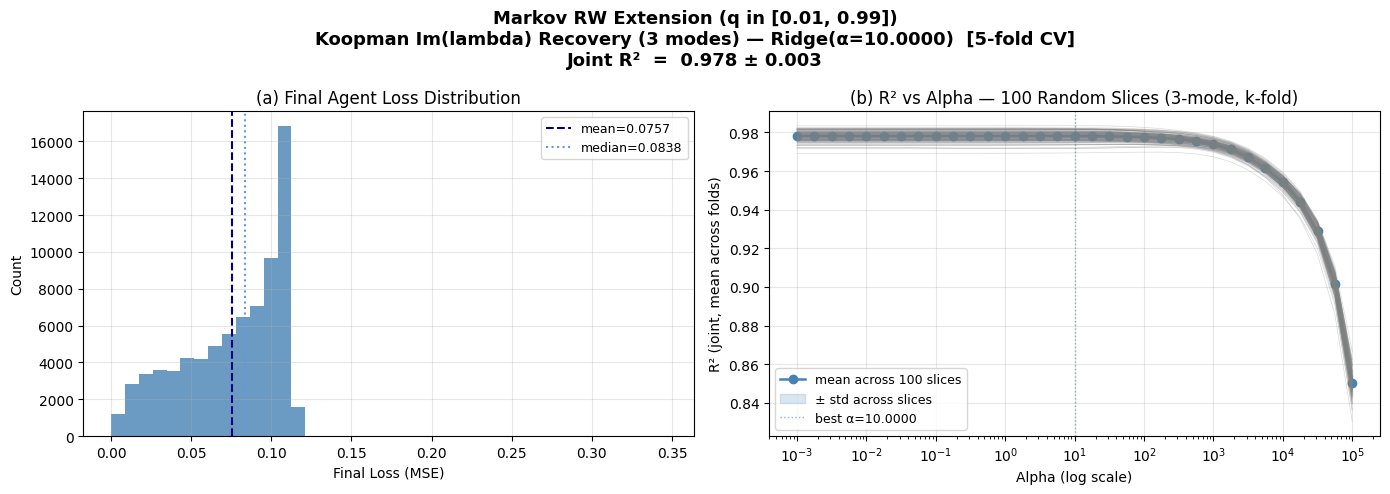

Figure 1 saved to tim_x_markov_rw_results_M_10_q_0.01_0.99_n_5000_inits_15_modes_3_s_32_h_32_t_200_nep_100.png


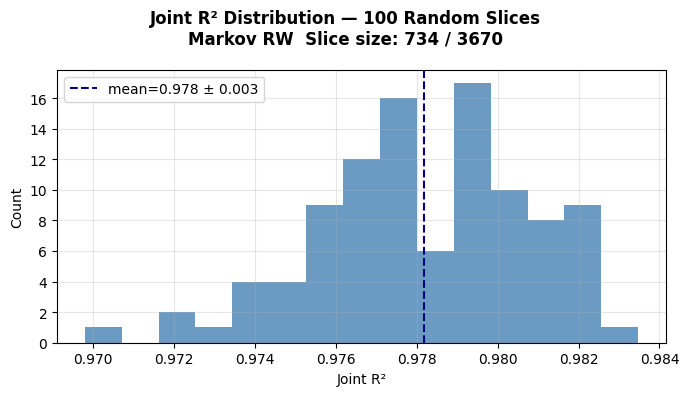

Figure 2 saved to tim_x_markov_rw_dist_M_10_q_0.01_0.99_n_5000_inits_15_modes_3_s_32_h_32_t_200_nep_100.png

Summary:
  Mean Joint R² : 0.978 ± 0.003
  Min / Max     : 0.970 / 0.983


In [11]:
# ============================================================
# Cell 11 (TIM III Markov) | Visualization — Random Slice Results
# Two figures:
#   Fig 1: Loss histogram + mean alpha curve across P slices
#   Fig 2: Distribution of Joint R² values across P slices
# ============================================================

COLORS = ["steelblue", "darkorange", "seagreen"]

best_idx      = int(np.argmax(probe_mean_r2_curve))
best_alpha    = probe_ridge_alphas[best_idx]
joint_r2_mean = probe_mean_r2_curve[best_idx]
joint_r2_std  = probe_std_r2_curve[best_idx]


# ── Figure 1: loss histogram + mean alpha curve ──────────────
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle(
    f"Markov RW Extension (q in [{Q_MIN}, {Q_MAX}])\n"
    f"Koopman Im(lambda) Recovery ({N_PROBE_MODES} modes) — "
    f"Ridge(α={best_alpha:.4f})  [{PROBE_K_FOLDS}-fold CV]\n"
    f"Joint R²  =  {joint_r2_mean:.3f} ± {joint_r2_std:.3f}",
    fontsize=13, fontweight="bold",
)

ax0 = axes[0]
ax0.hist(agent_losses.flatten(), bins=40, color="steelblue",
         edgecolor="none", alpha=0.8)
ax0.axvline(np.mean(agent_losses), color="navy",
            linewidth=1.5, linestyle="--",
            label=f"mean={np.mean(agent_losses):.4f}")
ax0.axvline(np.median(agent_losses), color="cornflowerblue",
            linewidth=1.5, linestyle=":",
            label=f"median={np.median(agent_losses):.4f}")
ax0.set_title("(a) Final Agent Loss Distribution", fontsize=12)
ax0.set_xlabel("Final Loss (MSE)")
ax0.set_ylabel("Count")
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.3)

ax1 = axes[1]
ax1.semilogx(probe_ridge_alphas, probe_mean_r2_curve,
             color="steelblue", linewidth=1.8, marker="o",
             label=f"mean across {N_RANDOM_SLICES} slices")
ax1.fill_between(probe_ridge_alphas,
                 probe_mean_r2_curve - probe_std_r2_curve,
                 probe_mean_r2_curve + probe_std_r2_curve,
                 color="steelblue", alpha=0.2, label="± std across slices")
for p in range(N_RANDOM_SLICES):
    ax1.semilogx(probe_ridge_alphas, random_all_mean_r2_curves[p],
                 color="grey", linewidth=0.5, alpha=0.3)
ax1.axvline(best_alpha, color="steelblue", linewidth=1.0,
            linestyle=":", alpha=0.6, label=f"best α={best_alpha:.4f}")
ax1.set_title(f"(b) R² vs Alpha — {N_RANDOM_SLICES} Random Slices "
              f"({N_PROBE_MODES}-mode, k-fold)", fontsize=12)
ax1.set_xlabel("Alpha (log scale)")
ax1.set_ylabel("R² (joint, mean across folds)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

fig1.tight_layout()
fig1_name = (f"tim_x_markov_rw_results"
             f"_M_{M_CYCLIC}_q_{Q_MIN}_{Q_MAX}"
             f"_n_{N_ENVS}_inits_{N_INITS}_modes_{N_PROBE_MODES}"
             f"_s_{STATE_DIM}_h_{MLP_HIDDEN_DIM}"
             f"_t_{T_STEPS}_nep_{N_EPOCHS_PER_ENV}.png")
fig1.savefig(fig1_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 1 saved to {fig1_name}")


# ── Figure 2: distribution of Joint R² values ────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.suptitle(
    f"Joint R² Distribution — {N_RANDOM_SLICES} Random Slices\n"
    f"Markov RW  Slice size: {SLICE_SIZE} / {TOTAL_PARAM_DIM}",
    fontsize=12, fontweight="bold",
)
ax2.hist(random_all_joint_r2, bins=min(N_RANDOM_SLICES, 15),
         color="steelblue", edgecolor="none", alpha=0.8)
ax2.axvline(random_joint_r2_mean, color="navy", linewidth=1.5,
            linestyle="--",
            label=f"mean={random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
ax2.set_xlabel("Joint R²")
ax2.set_ylabel("Count")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()

fig2_name = (f"tim_x_markov_rw_dist"
             f"_M_{M_CYCLIC}_q_{Q_MIN}_{Q_MAX}"
             f"_n_{N_ENVS}_inits_{N_INITS}_modes_{N_PROBE_MODES}"
             f"_s_{STATE_DIM}_h_{MLP_HIDDEN_DIM}"
             f"_t_{T_STEPS}_nep_{N_EPOCHS_PER_ENV}.png")
fig2.savefig(fig2_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 2 saved to {fig2_name}")

print(f"\nSummary:")
print(f"  Mean Joint R² : {random_joint_r2_mean:.3f} ± {random_joint_r2_std:.3f}")
print(f"  Min / Max     : {random_all_joint_r2.min():.3f} / "
      f"{random_all_joint_r2.max():.3f}")